In [8]:
import os

import pandas as pd
import string

## Keras
from keras.layers import Dense, Flatten, SimpleRNN, Embedding, Input
from keras import Sequential

## nltk
import nltk
from nltk.corpus import stopwords, re
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

## sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

In [10]:
df = pd.read_csv("/content/imbd.csv")
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [11]:
df.isnull().sum()

,0
review,0
sentiment,0


In [12]:
df.shape

(50000, 2)

## Preprocessing Methods

In [13]:
def rem_stopwords(text):
    words = stopwords.words('english')

    return " ".join(
        word for word in text.split() if word.lower() not in words
    )

def to_lower(text):
    return "".join(
        text.lower()
    )

def rem_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'', text)

def rem_punctuations(text):
    exclude = string.punctuation
    return text.translate(str.maketrans('', '', exclude))

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

def lemmatization(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalpha()]
    return " ".join(tokens)

def tokenize(text):
    tokenizer = word_tokenize(text)
    return tokenizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [14]:
df_rem = df
df_rem["review"] = df["review"].apply(to_lower)

df_rem["review"] = df["review"].apply(rem_stopwords)

In [16]:
df_rem["review"] = df_rem["review"].apply(rem_tags)
df_rem["review"] = df_rem["review"].apply(rem_punctuations)

In [ ]:
print(df_rem["review"])

0        one reviewers mentioned watching 1 oz episode ...
1        wonderful little production the filming techni...
2        thought wonderful way spend time hot summer we...
3        basically theres family little boy jake thinks...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job creative original...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary schools n...
49998    going disagree previous comment side maltin on...
49999    one expects star trek movies high art fans exp...
Name: review, Length: 50000, dtype: object


In [15]:
df_rem["review"] = df_rem["review"].apply(lemmatization)

In [17]:
## Tokenizing
df_rem["review"]= df_rem["review"].apply(tokenize)

In [18]:
df_rem["review"]

,review
0,"[one, reviewer, mentioned, watching, oz, episo..."
1,"[wonderful, little, production, br, br, the, f..."
2,"[thought, wonderful, way, spend, time, hot, su..."
3,"[basically, there, family, little, boy, jake, ..."
4,"[petter, mattei, love, time, money, visually, ..."
...,...
49995,"[thought, movie, right, good, job, creative, o..."
49996,"[bad, plot, bad, dialogue, bad, acting, idioti..."
49997,"[catholic, taught, parochial, elementary, scho..."
49998,"[going, disagree, previous, comment, side, mal..."


In [19]:
df['clean_review'] = df['review'].apply(lambda tokens: ' '.join(tokens))
X = df['clean_review']
y = df_rem["sentiment"]

encode = LabelEncoder()
y = encode.fit_transform(y,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, stratify= y, random_state=42
)

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_seq = pad_sequences(X_train_seq, maxlen=200)
X_test_seq = pad_sequences(X_test_seq, maxlen=200)

In [22]:
model = Sequential([
    Input(shape=(200,)),
    Embedding(input_dim=10000, output_dim=128),
    SimpleRNN(64),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
import tensorflow as tf
with tf.device('/GPU:0'):
  history = model.fit(X_train_seq, y_train, validation_data= (X_test_seq, y_test), epochs = 5)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7621 - loss: 0.4799 - val_accuracy: 0.8424 - val_loss: 0.3654
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8419 - loss: 0.3723 - val_accuracy: 0.5648 - val_loss: 0.6919
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7176 - loss: 0.5505 - val_accuracy: 0.6086 - val_loss: 0.6468
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.7825 - loss: 0.4592 - val_accuracy: 0.7598 - val_loss: 0.5014
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8759 - loss: 0.3062 - val_accuracy: 0.8385 - val_loss: 0.3691


In [25]:
pred = model.predict(X_test_seq)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [28]:
y_pred = (pred > 0.5).astype(int)

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      5000
           1       0.85      0.83      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



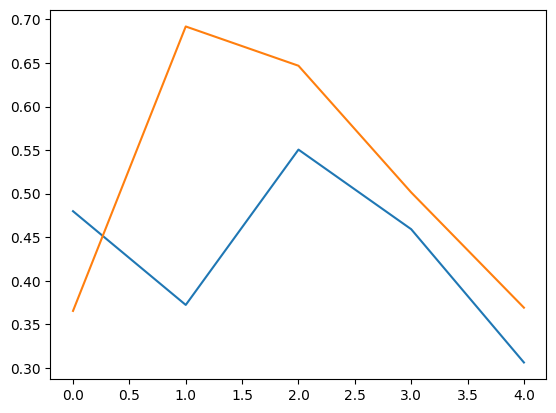

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [31]:
## Saving the trained model
model.save("sentiment_rnn.keras")

In [32]:
## Saving Tokenizer
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)